# Modal eval results — visual analysis

Loads the per-pedestrian ADE/FDE arrays produced by the leave-one-out eval runs on Modal
(`modal_eval.py` → `mid-data:/eval_results`, pulled into `../modal_eval_results/`) and turns
them into a few plots.

Every `.npz` holds: `ade`, `fde` (scalar means), `ade_per_pedestrian`, `fde_per_pedestrian`
(one number per pedestrian), and `n_pedestrians`.

These runs use **DDIM fast sampling (10 steps, Best-of-20)** — not the full 100-step DDPM
chain the paper reports, so a small gap to the paper numbers is expected.

## Load every result file

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# folder holds one .npz per leave-one-out fold
RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "modal_eval_results"))
FIG_DIR = os.path.join(os.getcwd(), "figures")
os.makedirs(FIG_DIR, exist_ok=True)

SCENE_ORDER = ["eth", "hotel", "univ", "zara1", "zara2"]

# Paper Best-of-20 reference numbers (full DDPM chain) for comparison.
PAPER = {
    "eth":   (0.39, 0.66),
    "hotel": (0.13, 0.22),
    "univ":  (0.22, 0.45),
    "zara1": (0.17, 0.30),
    "zara2": (0.13, 0.27),
}

results = {}
for path in sorted(glob.glob(os.path.join(RESULTS_DIR, "*.npz"))):
    scene = os.path.basename(path).split("_")[0]
    d = np.load(path)
    results[scene] = {
        "ade": float(d["ade"]),
        "fde": float(d["fde"]),
        "ade_arr": d["ade_per_pedestrian"],
        "fde_arr": d["fde_per_pedestrian"],
        "n": int(d["n_pedestrians"]),
    }

# keep a stable scene order for plotting
scenes = [s for s in SCENE_ORDER if s in results]
print(f"Loaded {len(scenes)} folds from {RESULTS_DIR}: {scenes}")

Loaded 5 folds from /Users/dhawaldixit/projects/ddpm/modal_eval_results: ['eth', 'hotel', 'univ', 'zara1', 'zara2']


## Summary table

Scalar ADE/FDE per scene, the pedestrian count behind each number, and the gap to the paper.

In [2]:
header = f"{'scene':<8}{'ADE':>8}{'FDE':>8}{'n_ped':>8}{'paper ADE':>11}{'paper FDE':>11}"
print(header)
print("-" * len(header))
ades, fdes = [], []
for s in scenes:
    r = results[s]
    ades.append(r["ade"]); fdes.append(r["fde"])
    pa, pf = PAPER.get(s, (np.nan, np.nan))
    print(f"{s:<8}{r['ade']:>8.4f}{r['fde']:>8.4f}{r['n']:>8}{pa:>11.2f}{pf:>11.2f}")
print("-" * len(header))
print(f"{'mean':<8}{np.mean(ades):>8.4f}{np.mean(fdes):>8.4f}"
      f"{sum(results[s]['n'] for s in scenes):>8}"
      f"{np.mean([PAPER[s][0] for s in scenes]):>11.2f}"
      f"{np.mean([PAPER[s][1] for s in scenes]):>11.2f}")

scene        ADE     FDE   n_ped  paper ADE  paper FDE
------------------------------------------------------
eth       0.4508  0.7985     364       0.39       0.66
hotel     0.1694  0.3029    1197       0.13       0.22
univ      0.2237  0.4560   24334       0.22       0.45
zara1     0.2500  0.5023    2356       0.17       0.30
zara2     0.1677  0.3327    5910       0.13       0.27
------------------------------------------------------
mean      0.2523  0.4785   34161       0.21       0.38


## ADE / FDE per scene vs. the paper

Our DDIM-10 numbers next to the paper's full-chain numbers, so the gap per scene is visible at a glance.

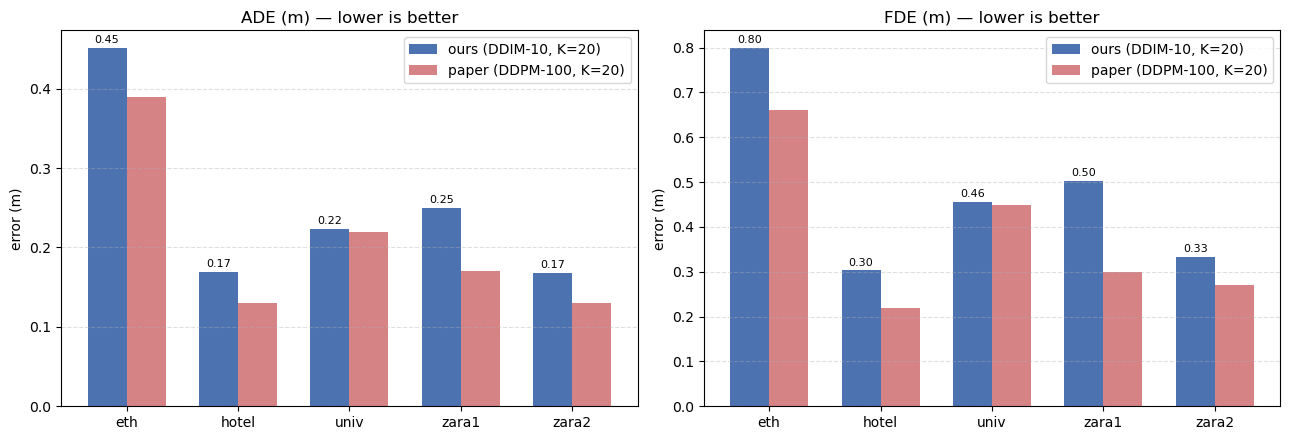

In [3]:
x = np.arange(len(scenes))
width = 0.35
paper_ade = [PAPER[s][0] for s in scenes]
paper_fde = [PAPER[s][1] for s in scenes]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, ours, paper, title in [
    (axes[0], ades, paper_ade, "ADE (m) — lower is better"),
    (axes[1], fdes, paper_fde, "FDE (m) — lower is better"),
]:
    b1 = ax.bar(x - width/2, ours, width, label="ours (DDIM-10, K=20)", color="#4C72B0")
    b2 = ax.bar(x + width/2, paper, width, label="paper (DDPM-100, K=20)", color="#C44E52", alpha=0.7)
    ax.set_xticks(x); ax.set_xticklabels(scenes)
    ax.set_title(title); ax.set_ylabel("error (m)")
    ax.bar_label(b1, fmt="%.2f", padding=2, fontsize=8)
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "modal_eval_ade_fde_bars.png"), dpi=150, bbox_inches="tight")
plt.show()

## Per-pedestrian error distributions

The scalar ADE/FDE above is just an average. These histograms show the spread: where most
pedestrians land, and how long the high-error tail is. A long tail means a handful of hard
pedestrians (sharp turns, stops, near scene edges) drag the mean up.

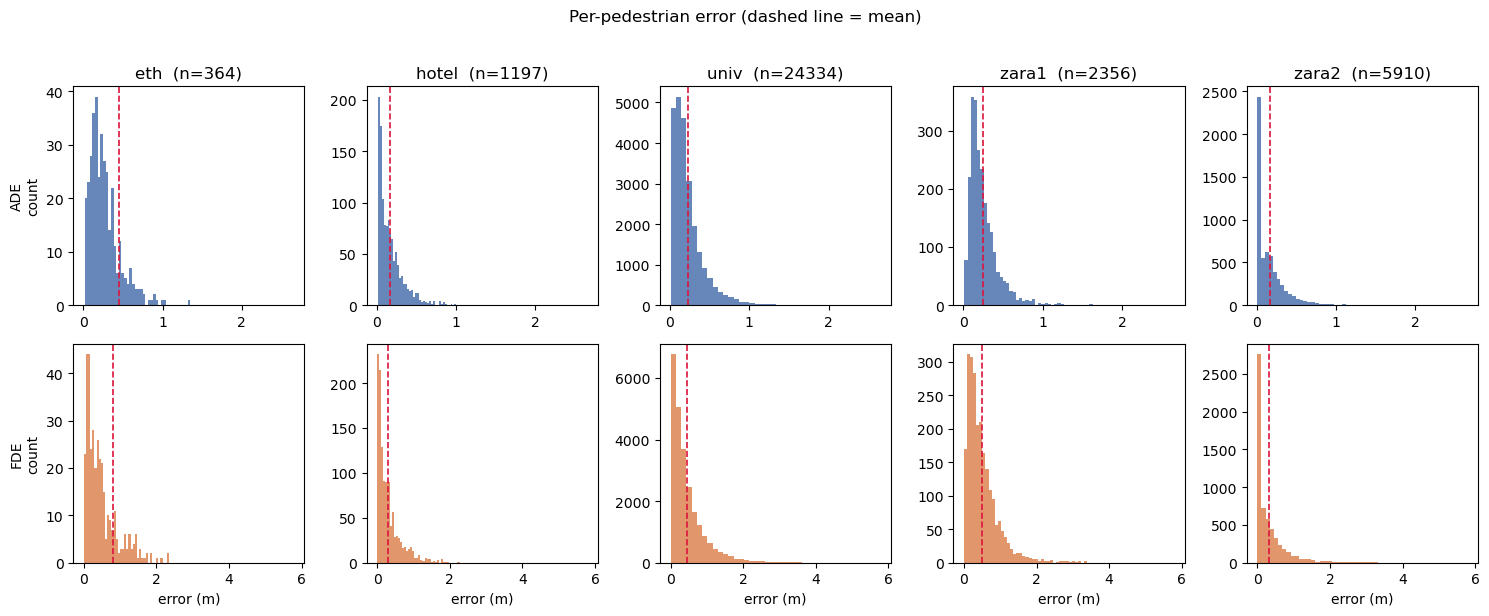

In [4]:
fig, axes = plt.subplots(2, len(scenes), figsize=(3.0 * len(scenes), 6), sharex="row")

for j, s in enumerate(scenes):
    r = results[s]
    # ADE row
    ax = axes[0, j]
    ax.hist(r["ade_arr"], bins=40, color="#4C72B0", alpha=0.85)
    ax.axvline(r["ade"], color="crimson", linestyle="--", lw=1.2)
    ax.set_title(f"{s}  (n={r['n']})")
    if j == 0:
        ax.set_ylabel("ADE\ncount")
    # FDE row
    ax = axes[1, j]
    ax.hist(r["fde_arr"], bins=40, color="#DD8452", alpha=0.85)
    ax.axvline(r["fde"], color="crimson", linestyle="--", lw=1.2)
    ax.set_xlabel("error (m)")
    if j == 0:
        ax.set_ylabel("FDE\ncount")

fig.suptitle("Per-pedestrian error (dashed line = mean)", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "modal_eval_histograms.png"), dpi=150, bbox_inches="tight")
plt.show()

## Spread side by side (box plots)

Same data, but stacked so the scenes are directly comparable. The box is the middle 50% of
pedestrians, the line inside is the median, and the points past the whiskers are the hard tail.

/var/folders/yj/ycyzcv451fsg_7q8ncrcy3zm0000gn/T/ipykernel_96695/1986232444.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=scenes, showfliers=True, patch_artist=True,
/var/folders/yj/ycyzcv451fsg_7q8ncrcy3zm0000gn/T/ipykernel_96695/1986232444.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=scenes, showfliers=True, patch_artist=True,


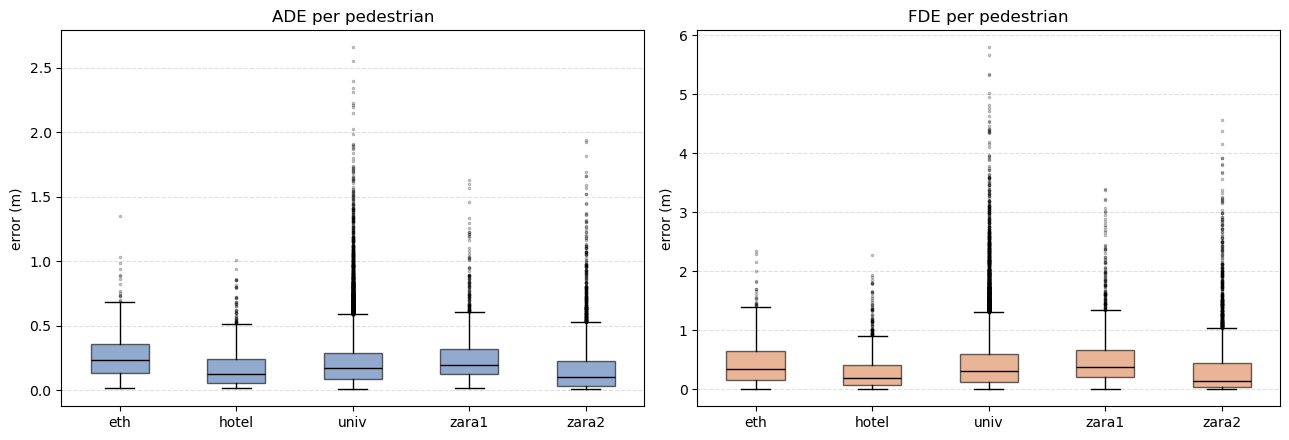

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, key, title, color in [
    (axes[0], "ade_arr", "ADE per pedestrian", "#4C72B0"),
    (axes[1], "fde_arr", "FDE per pedestrian", "#DD8452"),
]:
    data = [results[s][key] for s in scenes]
    bp = ax.boxplot(data, labels=scenes, showfliers=True, patch_artist=True,
                    flierprops=dict(marker=".", markersize=3, alpha=0.3))
    for patch in bp["boxes"]:
        patch.set_facecolor(color); patch.set_alpha(0.6)
    for med in bp["medians"]:
        med.set_color("black")
    ax.set_title(title); ax.set_ylabel("error (m)")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "modal_eval_boxplots.png"), dpi=150, bbox_inches="tight")
plt.show()

## How many pedestrians are 'easy' vs 'hard' (CDF)

Reading up from the x-axis: the curve tells you the fraction of pedestrians whose error is at or
below a given distance. A curve that shoots up fast and flattens means most pedestrians are easy
with a few hard outliers.

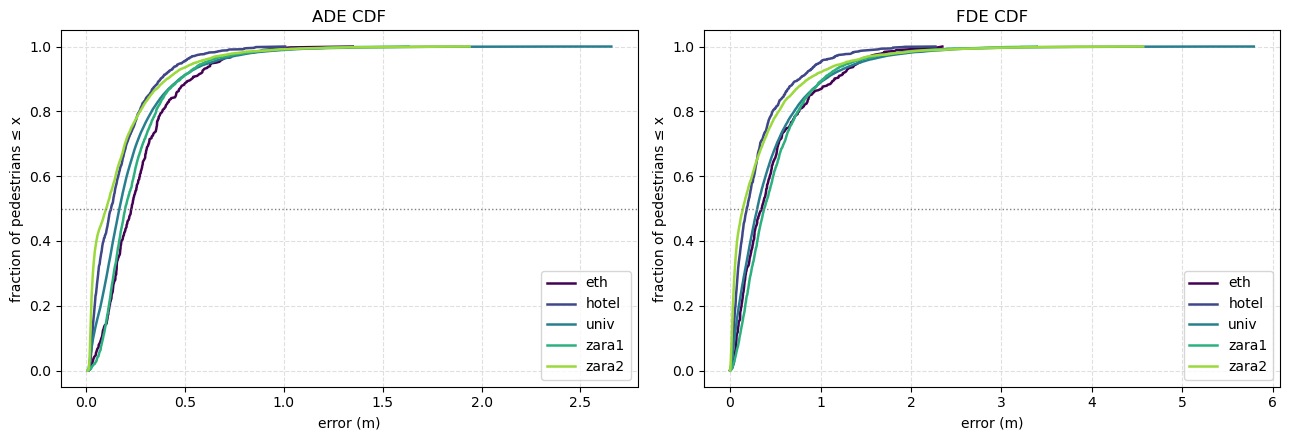

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
cmap = plt.cm.viridis(np.linspace(0, 0.85, len(scenes)))

for ax, key, title in [
    (axes[0], "ade_arr", "ADE CDF"),
    (axes[1], "fde_arr", "FDE CDF"),
]:
    for s, c in zip(scenes, cmap):
        arr = np.sort(results[s][key])
        cdf = np.arange(1, len(arr) + 1) / len(arr)
        ax.plot(arr, cdf, label=s, color=c, lw=1.8)
    ax.axhline(0.5, color="grey", linestyle=":", lw=1)  # median marker
    ax.set_title(title); ax.set_xlabel("error (m)"); ax.set_ylabel("fraction of pedestrians \u2264 x")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "modal_eval_cdf.png"), dpi=150, bbox_inches="tight")
plt.show()

## Findings — in plain words

**Overall.** Averaged over the five scenes we get **ADE ≈ 0.25 m** and **FDE ≈ 0.48 m**. ADE is the
average miss distance over the whole 4.8-second prediction; FDE is the miss at the very last step.
FDE is always bigger because errors build up the further ahead the model guesses.

**Which scenes are easy, which are hard.**
- **Hotel and Zara2** are the best (ADE ≈ 0.17 m). These are calmer scenes with steady walking, so
  the model nails most pedestrians.
- **Univ** sits in the middle (ADE ≈ 0.22 m) and is the most trustworthy number — it has ~24k
  pedestrians, so it is not swayed by a few odd cases.
- **ETH is the hardest** (ADE ≈ 0.45 m, FDE ≈ 0.80 m) and also the smallest (only 364 pedestrians).
  With so few people, a handful of tricky trajectories pull the average up a lot.

**What the distributions show.** The histograms and box plots are all skewed to the right: most
pedestrians have low error and sit on the left, with a thin tail of high-error cases stretching out.
The CDF says the same thing — the curves climb steeply early (the easy majority) then flatten (the
hard tail). So the mean is dragged up by a minority of hard pedestrians, the ones doing sharp turns,
stops, or appearing only briefly at the edge of the scene. The median pedestrian is noticeably
better than the mean.

**Versus the paper.** We track the paper's pattern (same easy/hard ordering of scenes) and on Univ
we essentially match it. We are behind mostly on ETH. Two reasons explain the gap: (1) these runs
use **DDIM with only 10 steps** for speed instead of the full 100-step DDPM chain, which trades a
little accuracy for ~10x faster sampling, and (2) limited training epochs. The fact that the
ordering and the easy-scene numbers line up is good evidence the implementation is correct; the
remaining gap is a budget/sampling-speed tradeoff, not a broken model.